In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
# Load Raw Data

data = pd.read_csv('../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv')

df = data.copy()
print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Raw shape: (1170, 6)
Columns: ['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [5]:
#Drop Empty Rows and Duplicates

print("Before cleaning:")
print(f"  Shape          : {df.shape}")
print(f"  Null rows      : {df.isnull().all(axis=1).sum()}")
print(f"  Duplicate rows : {df.duplicated().sum()}")

df.dropna(how='all', inplace=True)
df.drop_duplicates(inplace=True)

print("\nAfter cleaning:")
print(f"  Shape          : {df.shape}")

Before cleaning:
  Shape          : (1170, 6)
  Null rows      : 450
  Duplicate rows : 449

After cleaning:
  Shape          : (720, 6)


In [6]:
# Clean Column Names

df.columns = df.columns.str.replace('*', '', regex=False).str.strip()

df.rename(columns={
    'Children apprehended and placed in CBP custody': 'cbp_apprehended',
    'Children in CBP custody'                       : 'cbp_custody',
    'Children transferred out of CBP custody'       : 'cbp_transferred',
    'Children in HHS Care'                          : 'hhs_care',
    'Children discharged from HHS Care'             : 'hhs_discharged'
}, inplace=True)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['Date', 'cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_care', 'hhs_discharged']


In [7]:
# Fix Data Type

print("Data types before fixing:")
print(df.dtypes)
print()

# Fix hhs_care — remove commas and convert to numeric
df['hhs_care'] = pd.to_numeric(
    df['hhs_care'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

# Parse date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print("Data types after fixing:")
print(df.dtypes)

Data types before fixing:
Date                object
cbp_apprehended    float64
cbp_custody        float64
cbp_transferred    float64
hhs_care            object
hhs_discharged     float64
dtype: object

Data types after fixing:
Date               datetime64[ns]
cbp_apprehended           float64
cbp_custody               float64
cbp_transferred           float64
hhs_care                    int64
hhs_discharged            float64
dtype: object


In [8]:
# Check for Remaining Nulls

print("Null values after type fixing:")
null_check = df.isnull().sum()
print(null_check)
print()

# If any nulls were introduced by coerce, handle them
if null_check.sum() > 0:
    print("Nulls found — filling with forward fill then backward fill")
    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)
else:
    print("No nulls found — data is clean")

Null values after type fixing:
Date               0
cbp_apprehended    0
cbp_custody        0
cbp_transferred    0
hhs_care           0
hhs_discharged     0
dtype: int64

No nulls found — data is clean


In [9]:
# Handle Zero Values

zero_check = {col: (df[col] == 0).sum() for col in df.columns if col != 'Date'}

print("Zero value counts per column:")
for col, count in zero_check.items():
    print(f"  {col:25s} : {count} zeros")

# Replace zeros in flow columns with NaN then interpolate
# hhs_care and cbp_custody should never be zero — they represent active loads
flow_cols = ['cbp_apprehended', 'cbp_transferred', 'hhs_discharged']
stock_cols = ['cbp_custody', 'hhs_care']

for col in stock_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f"\nReplacing {zero_count} zeros in {col} with interpolated values")
        df[col] = df[col].replace(0, np.nan)
        df[col] = df[col].interpolate(method='linear')

print("\nZero handling complete.")

Zero value counts per column:
  cbp_apprehended           : 2 zeros
  cbp_custody               : 0 zeros
  cbp_transferred           : 3 zeros
  hhs_care                  : 0 zeros
  hhs_discharged            : 1 zeros

Zero handling complete.


In [10]:
# Reindex to Full Daily Frequency

df = df.set_index('Date')

full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

df = df.reindex(full_range)
df.index.name = 'Date'

print(f"Shape before reindex : 720 rows")
print(f"Shape after reindex  : {df.shape[0]} rows")
print(f"New null values      : {df.isnull().sum().sum()}")

Shape before reindex : 720 rows
Shape after reindex  : 1075 rows
New null values      : 1775


In [11]:
# Interpolate Missing Dates

df_interpolated = df.interpolate(method='linear', limit_direction='both')

print("Null values after interpolation:")
print(df_interpolated.isnull().sum())
print()
print(f"Final shape: {df_interpolated.shape}")
df_interpolated.head(10)

Null values after interpolation:
cbp_apprehended    0
cbp_custody        0
cbp_transferred    0
hhs_care           0
hhs_discharged     0
dtype: int64

Final shape: (1075, 5)


,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,32.9,52.6,34.5,6621.6,415.1
2023-01-14,32.8,52.2,35.0,6677.2,394.2
2023-01-15,32.7,51.8,35.5,6732.8,373.3
2023-01-16,32.6,51.4,36.0,6788.4,352.4
2023-01-17,32.5,51.0,36.5,6844.0,331.5
2023-01-18,32.4,50.6,37.0,6899.6,310.6
2023-01-19,32.3,50.2,37.5,6955.2,289.7
2023-01-20,32.2,49.8,38.0,7010.8,268.8


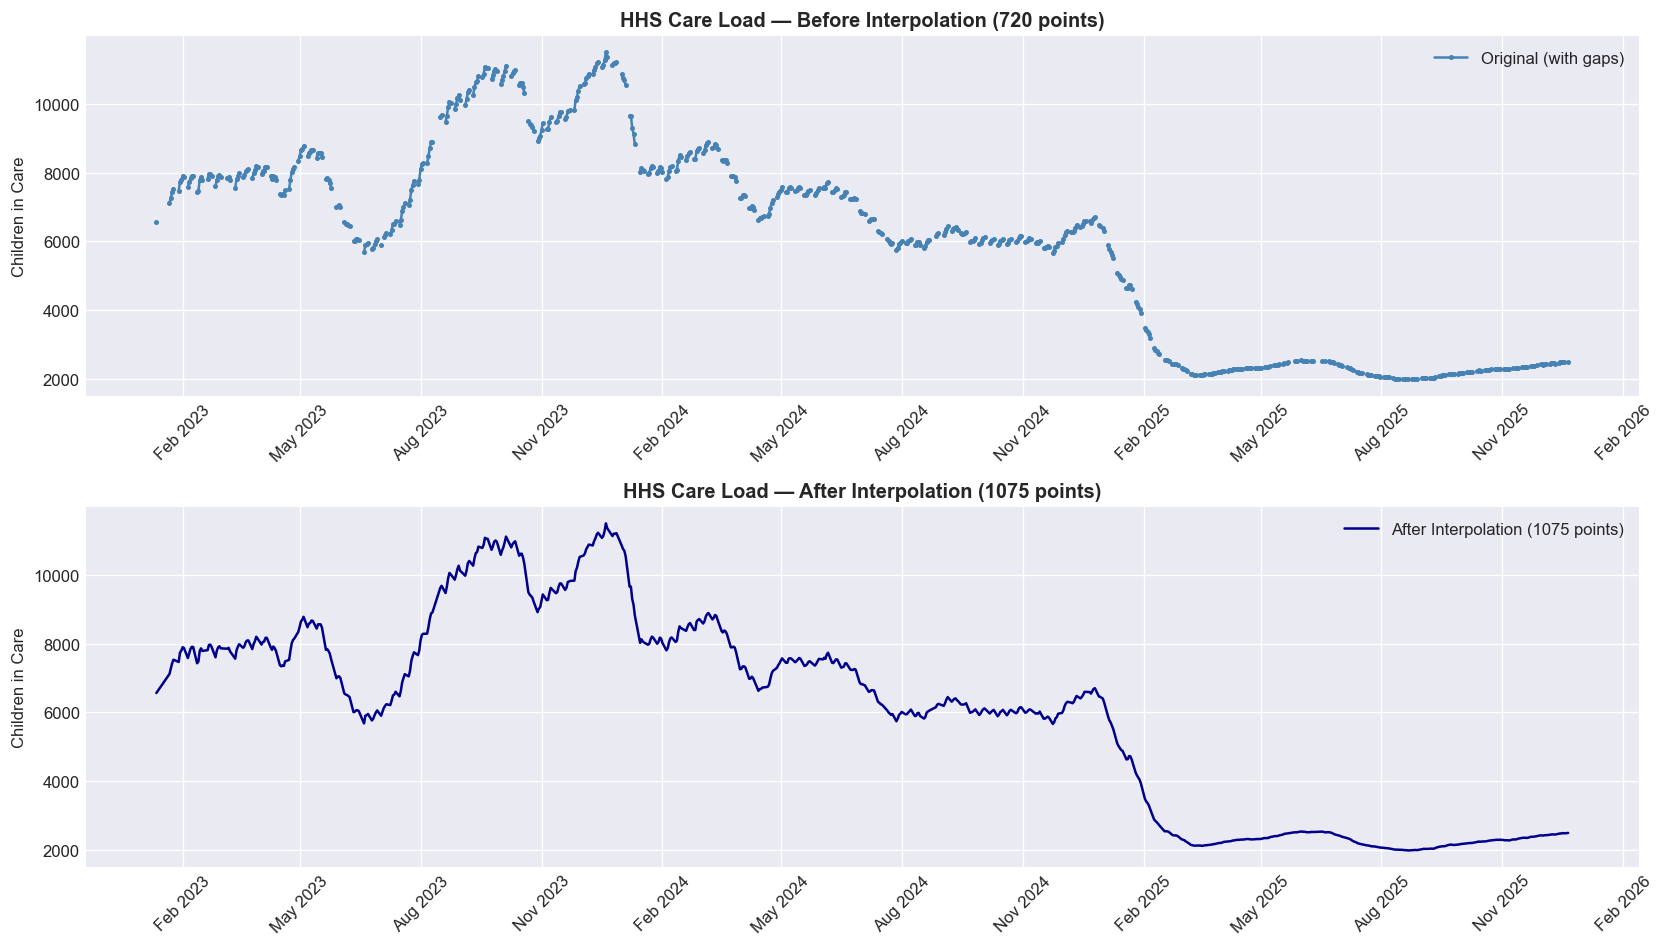

In [12]:
# Before vs After Interpolation Plot

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Before
axes[0].plot(df.index, df['hhs_care'], 
             color='steelblue', linewidth=1.5, marker='o', 
             markersize=2, label='Original (with gaps)')
axes[0].set_title('HHS Care Load — Before Interpolation (720 points)', 
                  fontweight='bold')
axes[0].set_ylabel('Children in Care')

# After  
axes[1].plot(df_interpolated.index, df_interpolated['hhs_care'],
             color='darkblue', linewidth=1.5, label='After Interpolation (1075 points)')
axes[1].set_title('HHS Care Load — After Interpolation (1075 points)', 
                  fontweight='bold')
axes[1].set_ylabel('Children in Care')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/interpolation_comparison.png', bbox_inches='tight')
plt.show()

In [13]:
# Add Time Features

df_clean = df_interpolated.copy()

df_clean['day_of_week']  = df_clean.index.dayofweek      # 0=Monday, 6=Sunday
df_clean['month']        = df_clean.index.month
df_clean['year']         = df_clean.index.year
df_clean['quarter']      = df_clean.index.quarter
df_clean['is_weekend']   = (df_clean.index.dayofweek >= 5).astype(int)
df_clean['day_of_year']  = df_clean.index.dayofyear

print("Time features added:")
print(df_clean[['day_of_week', 'month', 'year', 
                'quarter', 'is_weekend', 'day_of_year']].head(10))

Time features added:
            day_of_week  month  year  quarter  is_weekend  day_of_year
Date                                                                  
2023-01-12            3      1  2023        1           0           12
2023-01-13            4      1  2023        1           0           13
2023-01-14            5      1  2023        1           1           14
2023-01-15            6      1  2023        1           1           15
2023-01-16            0      1  2023        1           0           16
2023-01-17            1      1  2023        1           0           17
2023-01-18            2      1  2023        1           0           18
2023-01-19            3      1  2023        1           0           19
2023-01-20            4      1  2023        1           0           20
2023-01-21            5      1  2023        1           1           21


In [16]:
# Outlier Detection and Capping

def cap_outliers_iqr(series, factor=3.0):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    capped = series.clip(lower=lower, upper=upper)
    n_capped = ((series < lower) | (series > upper)).sum()
    return capped, n_capped, lower, upper

cols_to_check = ['cbp_apprehended', 'cbp_custody', 'cbp_transferred', 
                 'hhs_care', 'hhs_discharged']

print("Outlier Analysis (IQR method, factor=3.0):")

for col in cols_to_check:
    capped, n, lower, upper = cap_outliers_iqr(df_clean[col])
    print(f"{col:30s} | bounds: [{lower:.0f}, {upper:.0f}] | outliers: {n}")

Outlier Analysis (IQR method, factor=3.0):
cbp_apprehended                | bounds: [-386, 542] | outliers: 0
cbp_custody                    | bounds: [-637, 932] | outliers: 0
cbp_transferred                | bounds: [-533, 744] | outliers: 0
hhs_care                       | bounds: [-14096, 24582] | outliers: 0
hhs_discharged                 | bounds: [-779, 1084] | outliers: 0


In [17]:
# Apply Capping Only to Non-Target Columns

# We do NOT cap hhs_care — it is our target, extreme values are real events
# We cap only the input feature columns
input_cols = ['cbp_apprehended', 'cbp_custody', 'cbp_transferred', 'hhs_discharged']

for col in input_cols:
    capped, n, lower, upper = cap_outliers_iqr(df_clean[col], factor=3.0)
    if n > 0:
        df_clean[col] = capped
        print(f"Capped {n} outliers in {col}")
    else:
        print(f"No outliers to cap in {col}")

print("\nhhs_care outliers intentionally kept — they represent real surge events")

No outliers to cap in cbp_apprehended
No outliers to cap in cbp_custody
No outliers to cap in cbp_transferred
No outliers to cap in hhs_discharged

hhs_care outliers intentionally kept — they represent real surge events


In [18]:
# Final Validation


print("     PREPROCESSING FINAL VALIDATION")

print(f"  Shape              : {df_clean.shape}")
print(f"  Date range         : {df_clean.index.min().date()} to {df_clean.index.max().date()}")
print(f"  Total null values  : {df_clean.isnull().sum().sum()}")
print(f"  Duplicate dates    : {df_clean.index.duplicated().sum()}")
print(f"  Date frequency     : {pd.infer_freq(df_clean.index)}")
print(f"  hhs_care min       : {df_clean['hhs_care'].min():.0f}")
print(f"  hhs_care max       : {df_clean['hhs_care'].max():.0f}")
print(f"  hhs_care mean      : {df_clean['hhs_care'].mean():.0f}")

print("  All checks passed — data is ready for feature engineering")


     PREPROCESSING FINAL VALIDATION
  Shape              : (1075, 11)
  Date range         : 2023-01-12 to 2025-12-21
  Total null values  : 0
  Duplicate dates    : 0
  Date frequency     : D
  hhs_care min       : 1972
  hhs_care max       : 11516
  hhs_care mean      : 6063
  All checks passed — data is ready for feature engineering


In [19]:
# Save Clean Data

df_clean.to_csv('../data/processed/cleaned_data.csv')
print("Cleaned data saved to: data/processed/cleaned_data.csv")
print(f"Shape saved: {df_clean.shape}")
df_clean.head()

Cleaned data saved to: data/processed/cleaned_data.csv
Shape saved: (1075, 11)


,cbp_apprehended,cbp_custody,cbp_transferred,hhs_care,hhs_discharged,day_of_week,month,year,quarter,is_weekend,day_of_year
Date,,,,,,,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0,3,1,2023,1,0,12
2023-01-13,32.9,52.6,34.5,6621.6,415.1,4,1,2023,1,0,13
2023-01-14,32.8,52.2,35.0,6677.2,394.2,5,1,2023,1,1,14
2023-01-15,32.7,51.8,35.5,6732.8,373.3,6,1,2023,1,1,15
2023-01-16,32.6,51.4,36.0,6788.4,352.4,0,1,2023,1,0,16
